NetID: leahnl2

Assignment: Lab 6

Grade: _ / 6

Comments:


# CS448 - Lab 6: Denoising

In this lab we will use denoising to clean up some noisy recordings. We will use the following sounds:

Speech in a room: [https://drive.google.com/uc?export=download&id=1g5nbBpNbCjqs8cSoW0Lb-owe15tswDwW ]

ATC: [https://drive.google.com/uc?export=download&id=1fh5iL5qRj3-PUP_sG5-QE5DofACY_Hr5 ]

Speech with wind: [https://drive.google.com/uc?export=download&id=1g7TIkLpnWDFNUQYgCqIUoSOkk5EIK16_ ]



## Part 1. Cleaning up the sounds

Let’s start by cleaning up these sounds as best as we can. We will do a straightforward magnitude spectral subtraction. For all of these sounds there is only noise in the first few seconds of the recording so that you can learn a noise profile from there. Do the following:
Perform an STFT of the recordings

- Estimate the magnitude spectrum of the noise from the beginning of the recording
    - It’s up to you to figure out how many seconds to use (hint: look at the spectrogram)

- Perform spectral subtraction by subtracting that spectrum from the input’s magnitude STFT
    - Remember to clip any resulting negative values to zero
    - Try to find how much of the noise to subtract so that the output looks good

- Use the original signal’s phase to convert back to a time series.

Make a note of which examples sound the best and are easier to work with. Try to explain why.
At this point some of the outputs will exhibit “musical noise”. To minimize its effects apply a median filter on the denoised magnitude spectrogram to make it sound better (hint: ```scipy.signal.medfilt2```). How big should the median window be? Try different values and find which work best.


In [1]:
import utils
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [15]:
def plot_noisy_spectrum(noise_spectrum, sample_rate, duration):
    # compute frequency axis
    freqs = np.linspace(0, sample_rate / 2, noise_spectrum.shape[0])
    
    # plot graph
    plt.plot(freqs, noise_spectrum, color='c')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Avg Magnitude")
    plt.title(f"Spectrum of Noisy Section (time 0 to {duration}s)")
    plt.grid()

def perform_spectral_subtraction(sound_x, sound_sr, dft_size, duration, alpha, median_size):
    # define stft parameters
    hop_size = dft_size // 4
    hann_window = np.hanning(dft_size)

    # compute STFT and plot spectrogram
    spectrogram = utils.stft(sound_x, dft_size, hop_size, hann_window)
    plt.subplot(2, 2, 1)
    utils.plot_spectrogram(spectrogram, dft_size, hop_size, sound_sr, "Original", "magma")
    
    # compute number of frames for noisy section
    num_frames = int((duration * sound_sr) / hop_size)  
    
    # obtain and plot noisy section magnitudes
    magnitudes = np.abs(spectrogram)                     
    noise_spectrum = np.mean(magnitudes[:, :num_frames], axis=1)
    plt.subplot(2, 2, 2)
    plot_noisy_spectrum(noise_spectrum, sound_sr, duration)
    
    # perform spectral subtraction: x[t] = (||x[t]|| - alpha*||N[t]||)e^(i * angle(x[t]))
    denoised_spectrogram = np.clip(magnitudes - (alpha * noise_spectrum[:, np.newaxis]), 0, None)
    denoised_spectrogram = (denoised_spectrogram) * np.exp(1j * np.angle(spectrogram))
    
    # plot the denoised spectrogram
    plt.subplot(2, 2, 3)
    utils.plot_spectrogram(denoised_spectrogram, dft_size, hop_size, sound_sr, "Denoised", "magma")

    # median filter the denoised magnitude spectrum and plot it
    median_filtered_magnitudes = scipy.signal.medfilt2d(np.abs(denoised_spectrogram), median_size)
    median_denoised_spectrogram = median_filtered_magnitudes * np.exp(1j * np.angle(denoised_spectrogram))
    plt.subplot(2, 2, 4)
    utils.plot_spectrogram(median_denoised_spectrogram, dft_size, hop_size, sound_sr, "Median Filter Denoised", "magma")
    
    denoised_sound_x = utils.istft(median_denoised_spectrogram, dft_size, hop_size, hann_window)
    return denoised_sound_x

Room Speech (Original),Your browser does not support the audio element.


Room Speech (Denoised),Your browser does not support the audio element.


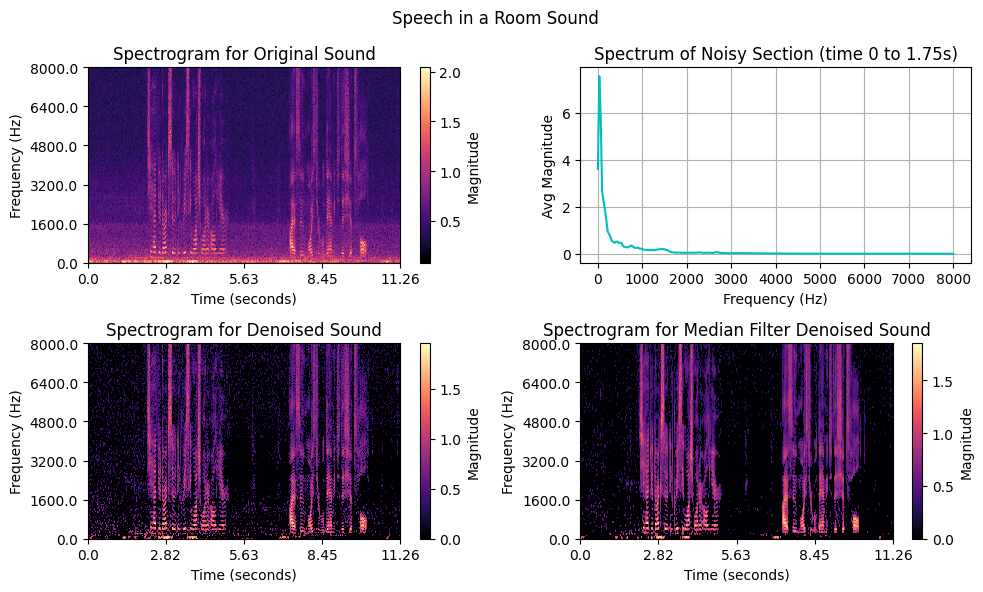

In [16]:
# YOUR CODE HERE

# create plot
plt.figure(figsize=(10, 6))
plt.suptitle("Speech in a Room Sound")

# load and play sound
room_speech_sr, room_speech_x = utils.wavreadfile("./data/room-speech.wav")
utils.sound(room_speech_x, room_speech_sr, "Room Speech (Original)")

# set spectral subtraction parameters and perform denoising
dft_size = 512
duration = 1.75
alpha = 1.45
median_size = 3

denoised_room_speech_x = perform_spectral_subtraction(room_speech_x, room_speech_sr, dft_size, duration, alpha, median_size)
utils.sound(denoised_room_speech_x, room_speech_sr, "Room Speech (Denoised)")

plt.tight_layout()
plt.show()

ATC (Original),Your browser does not support the audio element.


ATC (Denoised),Your browser does not support the audio element.


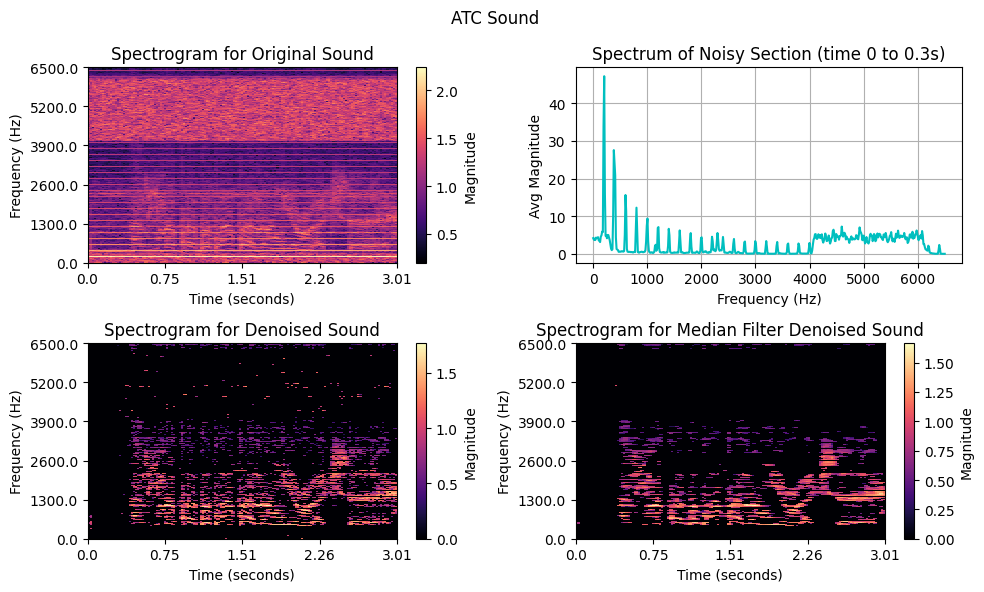

In [30]:
# YOUR CODE HERE

# create plot
plt.figure(figsize=(10, 6))
plt.suptitle("ATC Sound")

# load and play sound
aircomm_sr, aircomm_x = utils.wavreadfile("./data/aircomm.wav")
utils.sound(aircomm_x, aircomm_sr, "ATC (Original)")

# set spectral subtraction parameters and perform denoising
dft_size = 1024
duration = 0.3
alpha = 2.8
median_size = 3

denoised_aircomm_x = perform_spectral_subtraction(aircomm_x, aircomm_sr, dft_size, duration, alpha, median_size)
utils.sound(denoised_aircomm_x, aircomm_sr, "ATC (Denoised)")

plt.tight_layout()
plt.show()

C:\Users\leahl\Classes\CS448\lab-6-leahlud\utils.py:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, s =  scipy.io.wavfile.read(filename)


Wind Speech (Original),Your browser does not support the audio element.


Wind Speech (Denoised),Your browser does not support the audio element.


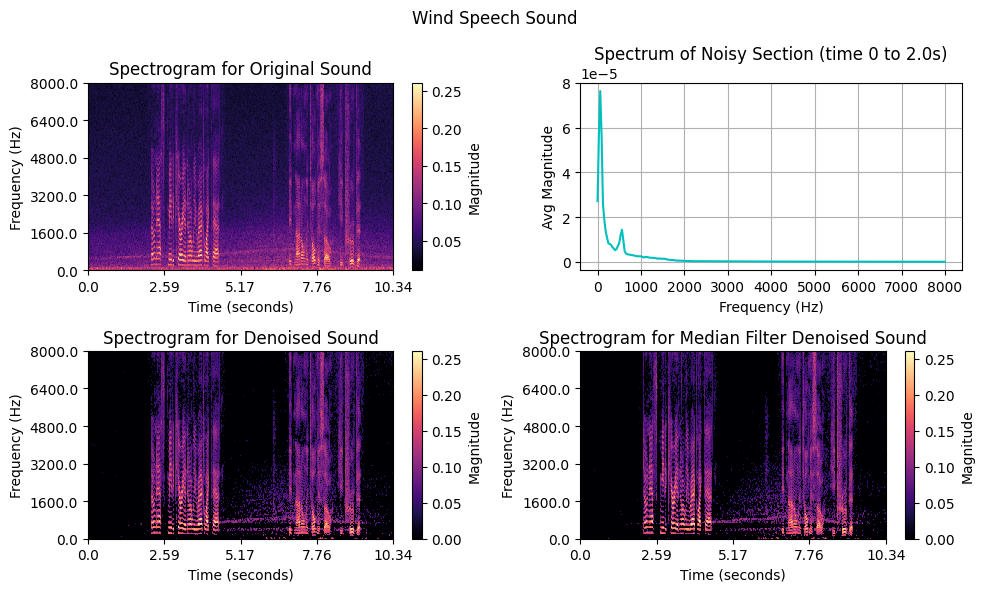

In [111]:
# YOUR CODE HERE

# create plot
plt.figure(figsize=(10, 6))
plt.suptitle("Wind Speech Sound")

# load and play sound
wind_speech_sr, wind_speech_x = utils.wavreadfile("./data/wind-speech.wav")
utils.sound(wind_speech_x, wind_speech_sr, "Wind Speech (Original)")

# set spectral subtraction parameters and perform denoising
dft_size = 512
duration = 2.0
alpha = 3
median_size = 1

denoised_wind_speech_x = perform_spectral_subtraction(wind_speech_x, wind_speech_sr, dft_size, duration, alpha, median_size)
utils.sound(denoised_wind_speech_x, wind_speech_sr, "Wind Speech (Denoised)")

plt.tight_layout()
plt.show()

**TODO: Explain which examples sound best and are easier to work with...**

The first two sounds sounded the best since the noise profile stayed relatively the same throughout the sound. Since the third sound had a noise profile that changed over time, the spectral subtraction failed to remove the noise later on when the wind sound increased to higher frequencies. Despite this, I found it easier to remove the noise (albeit only in the first few seconds) in the third sound compared to the others. I had to tweak the values a lot for the other two to get them to have a good balance of noise removal and preserving the details of the speech sounds. The second sound (ATC) benefited from a higher alpha value since there was so much noise, especially in the higher frequencies.

**TODO: Which median window size works best, and why?**

I found that smaller median window sizes (~3) worked best because they preserved the finer details of the spectrogram/sound. While higher values did remove more of the musical noise, they resulted in a blurred sound that did keep the nuanced parts of speech. For the speech in wind sound, I found that median filtering blurred the low frequencies too much and made the speech sound distorted, which led me to use a kernel size of 1 (which didn't apply median filtering).

## Part 2. Implement a Voice Activity Detector (VAD)


For the last sound we have an evolving noise profile, which causes problems since our noise description from the first two seconds isn’t accurate throughout. Because we’re lazy we want to automatically update the noise model and not to select it manually. To do so we need a VAD that lets us know when to gather noise statistics and when to denoise. Do the following:

- Take the square of the input waveform and lowpass filter it (a lot) to get an energy level over time
    - Experiment with the cutoff frequency so that you get a smooth energy-looking function
- Set a threshold over which we seem to have speech in the input
- Implement a real-time spectral subtraction denoiser
    - If an input frame is under threshold, it is noise
    - Keep track of the last few noise frames and their average amplitude will be your noise spectrum
    - If an input is over the threshold it is speech
    - Once you encounter speech perform spectral subtraction with the current noise estimate

In [112]:
def spectral_subtraction(frame_stft, noise_estimate, alpha):
    magnitudes = np.abs(frame_stft)  
    
    # perform spectral subtraction: x[t] = (||x[t]|| - alpha*||N[t]||)e^(i * angle(x[t]))
    denoised_frame_stft = np.clip(magnitudes - (alpha * noise_estimate), 0, None)
    denoised_frame_stft = (denoised_frame_stft) * np.exp(1j * np.angle(frame_stft))

    # median filter the denoised magnitude spectrum and plot it
    median_filtered_magnitudes = scipy.signal.medfilt(np.abs(denoised_frame_stft), kernel_size=1)
    median_denoised_frame_stft = median_filtered_magnitudes * np.exp(1j * np.angle(denoised_frame_stft))

    return median_denoised_frame_stft

Wind Speech (VAD Denoised),Your browser does not support the audio element.


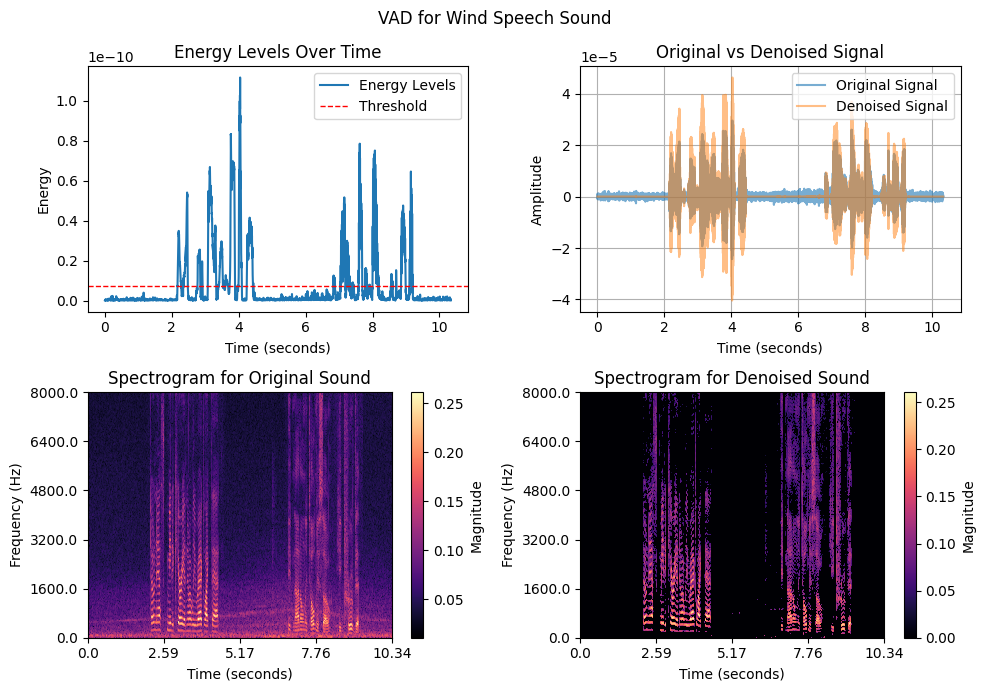

In [113]:
# YOUR CODE HERE

plt.figure(figsize=(10, 7))
plt.suptitle("VAD for Wind Speech Sound")

# take square of input waveform and lowpass filter it a lot
squared_waveform = wind_speech_x ** 2
lowpass_filter = scipy.signal.firwin(151, cutoff=0.005, window="hamming")
energy_levels = scipy.signal.lfilter(lowpass_filter, 1, squared_waveform)

# get threshold for detecting noise
threshold = np.percentile(energy_levels, 99.5)

# plot energy levels and threshold
plt.subplot(2, 2, 1)
plt.plot(np.arange(len(energy_levels)) / wind_speech_sr, energy_levels, label='Energy Levels')
plt.axhline(y=(threshold / 10), color='r', linestyle='--', linewidth=1, label='Threshold')
plt.title('Energy Levels Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Energy')
plt.legend()

# compute STFT of sound
dft_size = 512
hop_size = dft_size // 4
hann_window = np.hanning(dft_size)
stft = utils.stft(wind_speech_x, dft_size, hop_size, hann_window)


# take a few frames for the beginning noise (to help noise spectrum better remove noise)
num_frames = 5
magnitudes = np.abs(stft)                     
noise_spectrum_beginning = (magnitudes[:, :num_frames]).T

# perform real-time VAD and denoising
noise_buffer = None
denoised_stft = np.zeros_like(stft)
alpha = 4.8

for i in range(0, stft.shape[1]):
    
    # calculate current frame's energy
    frame = stft[:, i]
    frame_energy = np.mean(np.abs(frame)**2) 

    # check current frame is noise (i.e. under the threshold)
    if frame_energy < threshold:
        if noise_buffer is None:
            noise_buffer = np.abs(frame)
        else:
            noise_buffer = np.vstack((noise_buffer, np.abs(frame)))

            # check if number of noise frames exceeds intended number
            if noise_buffer.shape[0] > 20:
                noise_buffer = noise_buffer[1:, :]

    elif noise_buffer is not None:
        # compute the noise spectrum (use a few beginning and current noise frames) 
        noise_spectrum = np.mean(np.append(noise_spectrum_beginning, np.array(noise_buffer), axis=0), axis=0)

        # use spectral subtraction to remove the noise from the frame
        denoised_frame = spectral_subtraction(frame, noise_spectrum, alpha)
        denoised_stft[:, i] = denoised_frame

# play denoised sound
denoised_signal = utils.istft(denoised_stft, dft_size, hop_size, hann_window)
utils.sound(denoised_signal, wind_speech_sr, "Wind Speech (VAD Denoised)")

# plot the original and denoised signals
plt.subplot(2, 2, 2)
plt.plot(np.arange(len(wind_speech_x)) / wind_speech_sr, wind_speech_x, label='Original Signal', alpha=0.6)
plt.plot(np.arange(len(denoised_signal)) / wind_speech_sr, denoised_signal, label='Denoised Signal', alpha=0.5)
plt.title('Original vs Denoised Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# plot original and denoised spectrograms
plt.subplot(2, 2, 3)
utils.plot_spectrogram(stft, dft_size, hop_size, wind_speech_sr, "Original", "magma")

plt.subplot(2, 2, 4)
utils.plot_spectrogram(denoised_stft, dft_size, hop_size, wind_speech_sr, "Denoised", "magma")

plt.tight_layout()
plt.show()